# 1D Euler Solver — API Test Notebook

Interactive tests for the `numerical_solvers.euler` public API:
- Initial condition builders: `sod`, `riemann`, `from_steps`, `random_piecewise`
- Solvers: `generate_one`, `generate_n`
- Physics helpers: `primitive_to_conservative`, `conservative_to_primitive`, `sound_speed`

In [1]:
import torch
import matplotlib.pyplot as plt

from numerical_solvers.src.euler import (
    generate_one,
    generate_n,
    sod,
    riemann,
    from_steps,
    primitive_to_conservative,
    conservative_to_primitive,
    sound_speed,
)

%matplotlib inline

# Shared grid parameters
NX = 400
DX = 2.0 / NX
DT = 0.0003
NT = 500
GAMMA = 1.4

x = torch.arange(NX, dtype=torch.float64) * DX - 1.0

## 1. Sod Shock Tube

Classic benchmark: (rho, u, p) = (1, 0, 1) | (0.125, 0, 0.1). Should produce a left rarefaction, contact discontinuity, and right shock.

valid: True


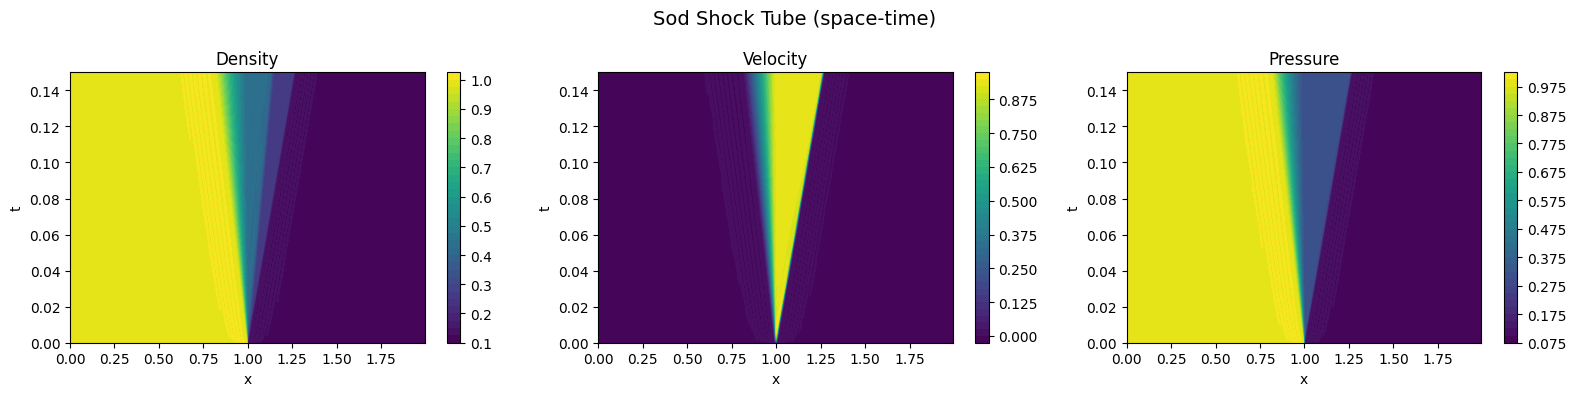

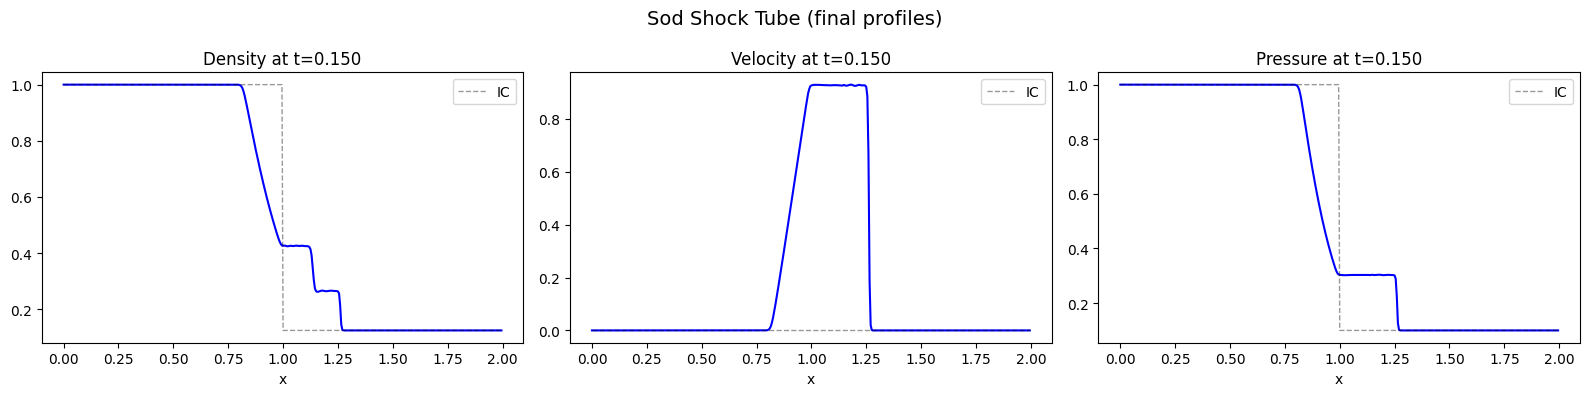

In [2]:
rho0, u0, p0 = sod(x, x_split=0.0)
sol = generate_one(rho0, u0, p0, dx=DX, dt=DT, nt=NT, gamma=GAMMA)
print(f"valid: {sol['valid']}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, key, title in zip(axes, ["rho", "u", "p"], ["Density", "Velocity", "Pressure"]):
    c = ax.contourf(sol["x"].numpy(), sol["t"].numpy(), sol[key].numpy(), levels=40, cmap="viridis")
    fig.colorbar(c, ax=ax)
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(title)
fig.suptitle("Sod Shock Tube (space-time)", fontsize=14)
fig.tight_layout()
plt.show()

# Profiles at final time
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, key, title in zip(axes, ["rho", "u", "p"], ["Density", "Velocity", "Pressure"]):
    ax.plot(sol["x"].numpy(), sol[key][-1].numpy(), "b-", lw=1.5)
    ax.plot(sol["x"].numpy(), sol[key][0].numpy(), "k--", lw=1, alpha=0.4, label="IC")
    ax.set_xlabel("x"); ax.set_title(f"{title} at t={sol['t'][-1]:.3f}")
    ax.legend()
fig.suptitle("Sod Shock Tube (final profiles)", fontsize=14)
fig.tight_layout()
plt.show()

## 2. Toro Test Problems

Standard benchmarks from Toro (2009) with non-zero velocities.

Toro 1 (modified Sod, u_L=0.75): valid=True
Toro 2 (double rarefaction): valid=True
Toro 3 (strong shock, u=0): valid=True
Toro 4 (colliding shocks): valid=True


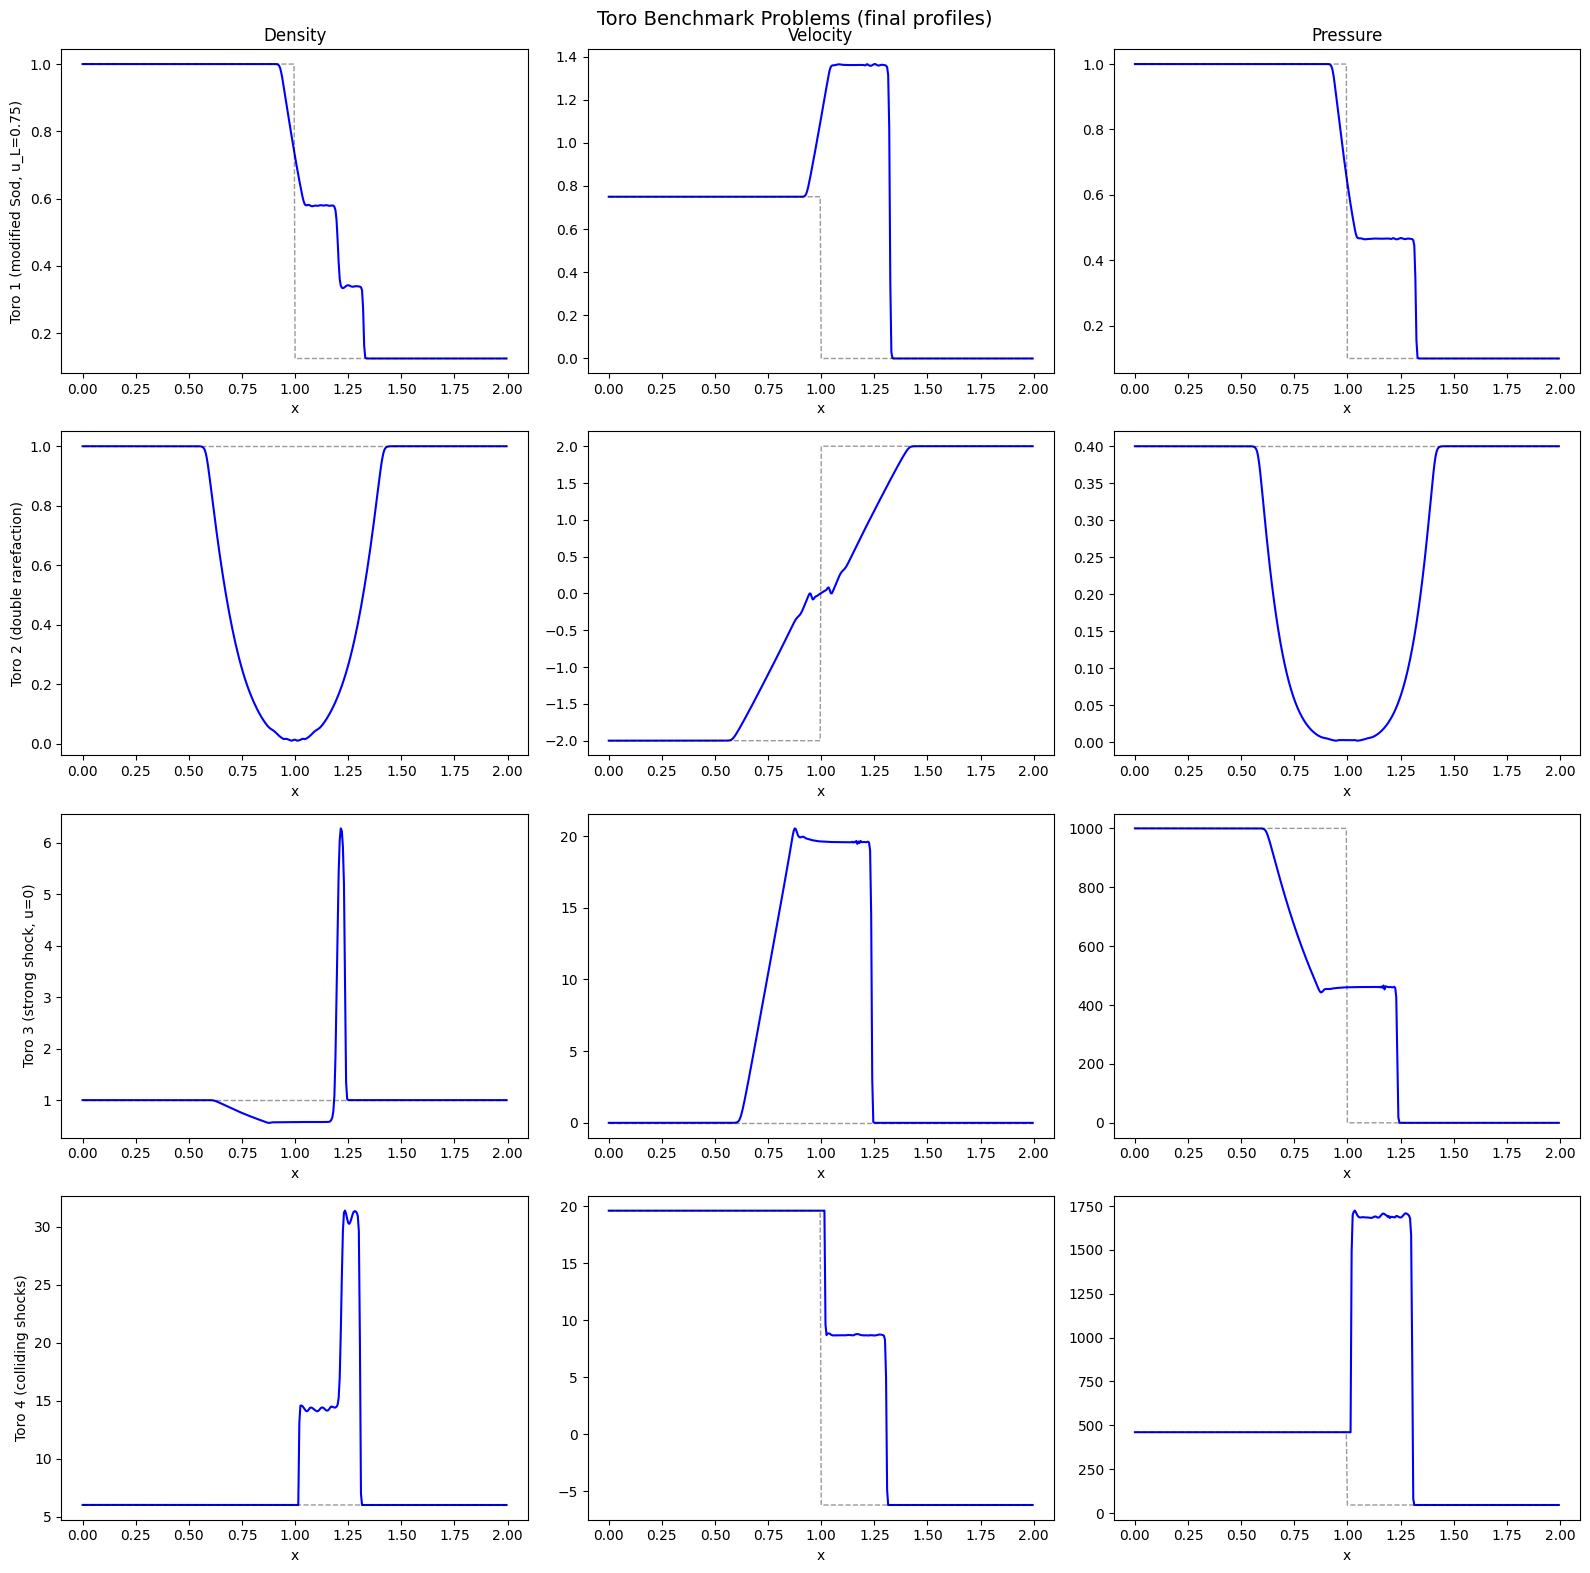

In [3]:
toro_tests = {
    "Toro 1 (modified Sod, u_L=0.75)": dict(
        rho_left=1.0, rho_right=0.125, u_left=0.75, u_right=0.0,
        p_left=1.0, p_right=0.1, dt=DT, nt=NT,
    ),
    "Toro 2 (double rarefaction)": dict(
        rho_left=1.0, rho_right=1.0, u_left=-2.0, u_right=2.0,
        p_left=0.4, p_right=0.4, dt=DT, nt=NT,
    ),
    "Toro 3 (strong shock, u=0)": dict(
        rho_left=1.0, rho_right=1.0, u_left=0.0, u_right=0.0,
        p_left=1000.0, p_right=0.01, dt=0.00005, nt=200,
    ),
    "Toro 4 (colliding shocks)": dict(
        rho_left=5.99924, rho_right=5.99242, u_left=19.5975, u_right=-6.19633,
        p_left=460.894, p_right=46.095, dt=0.00005, nt=500,
    ),
}

fig, axes = plt.subplots(len(toro_tests), 3, figsize=(16, 4 * len(toro_tests)))

for row, (name, params) in enumerate(toro_tests.items()):
    dt_t = params.pop("dt")
    nt_t = params.pop("nt")
    rho0, u0, p0 = riemann(x, x_split=0.0, **params)
    sol = generate_one(rho0, u0, p0, dx=DX, dt=dt_t, nt=nt_t, gamma=GAMMA)
    params["dt"] = dt_t; params["nt"] = nt_t  # restore

    for col, (key, title) in enumerate(zip(["rho", "u", "p"], ["Density", "Velocity", "Pressure"])):
        ax = axes[row, col]
        ax.plot(sol["x"].numpy(), sol[key][-1].numpy(), "b-", lw=1.5)
        ax.plot(sol["x"].numpy(), sol[key][0].numpy(), "k--", lw=1, alpha=0.4)
        ax.set_xlabel("x")
        ax.set_title(f"{title}" if row == 0 else "")
    axes[row, 0].set_ylabel(name, fontsize=10)
    print(f"{name}: valid={sol['valid']}")

fig.suptitle("Toro Benchmark Problems (final profiles)", fontsize=14)
fig.tight_layout()
plt.show()

## 3. Flux & Reconstruction Comparison

Compare HLLC vs HLL vs Rusanov, and 1st order vs WENO-5, on the Sod problem.

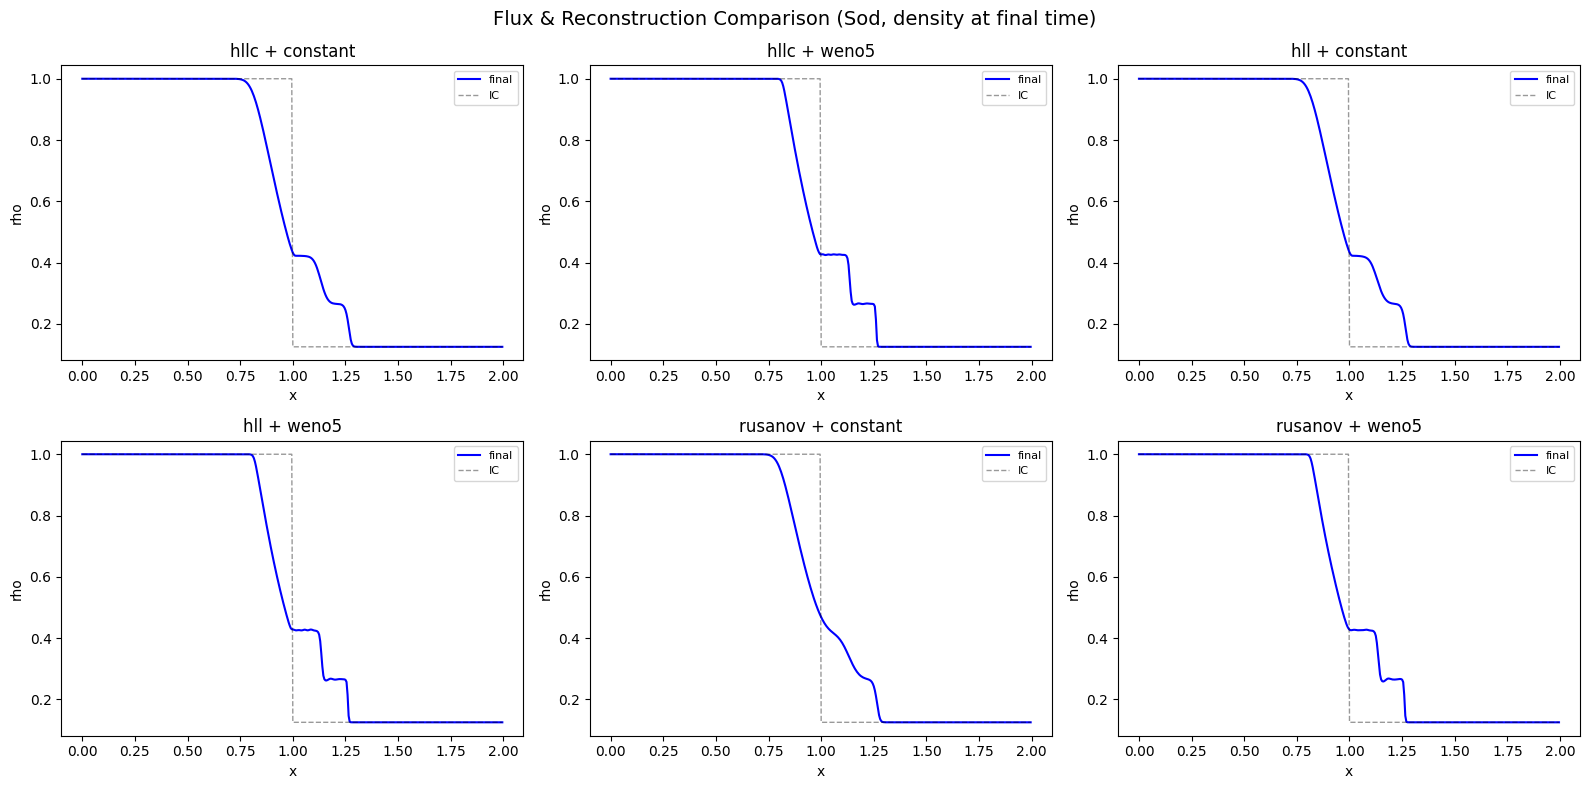

In [4]:
configs = [
    ("hllc", "constant"), ("hllc", "weno5"),
    ("hll", "constant"),  ("hll", "weno5"),
    ("rusanov", "constant"), ("rusanov", "weno5"),
]

rho0, u0, p0 = sod(x, x_split=0.0)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (flux, recon) in zip(axes.flat, configs):
    sol = generate_one(rho0, u0, p0, dx=DX, dt=DT, nt=NT, gamma=GAMMA,
                       flux_type=flux, reconstruction=recon)
    ax.plot(sol["x"].numpy(), sol["rho"][-1].numpy(), "b-", lw=1.5, label="final")
    ax.plot(sol["x"].numpy(), sol["rho"][0].numpy(), "k--", lw=1, alpha=0.4, label="IC")
    ax.set_xlabel("x"); ax.set_ylabel("rho")
    ax.set_title(f"{flux} + {recon}")
    ax.legend(fontsize=8)
fig.suptitle("Flux & Reconstruction Comparison (Sod, density at final time)", fontsize=14)
fig.tight_layout()
plt.show()

## 4. Boundary Conditions

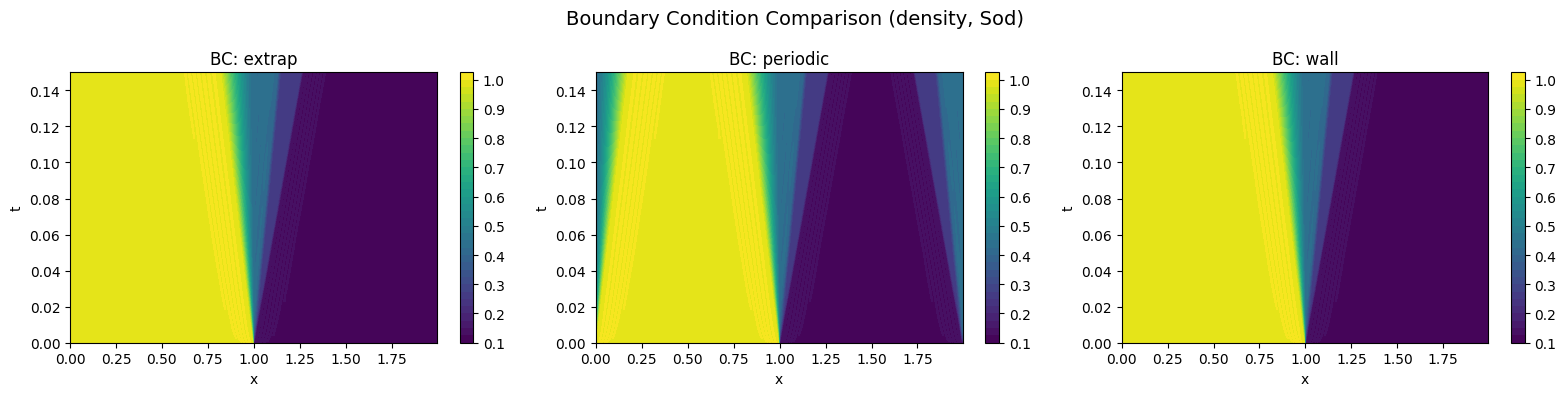

In [5]:
bc_types = ["extrap", "periodic", "wall"]
rho0, u0, p0 = sod(x, x_split=0.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, bc in zip(axes, bc_types):
    sol = generate_one(rho0, u0, p0, dx=DX, dt=DT, nt=NT, gamma=GAMMA, bc_type=bc)
    c = ax.contourf(sol["x"].numpy(), sol["t"].numpy(), sol["rho"].numpy(), levels=40, cmap="viridis")
    fig.colorbar(c, ax=ax)
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(f"BC: {bc}")
fig.suptitle("Boundary Condition Comparison (density, Sod)", fontsize=14)
fig.tight_layout()
plt.show()

## 5. Custom Piecewise IC (`from_steps`)

valid: True


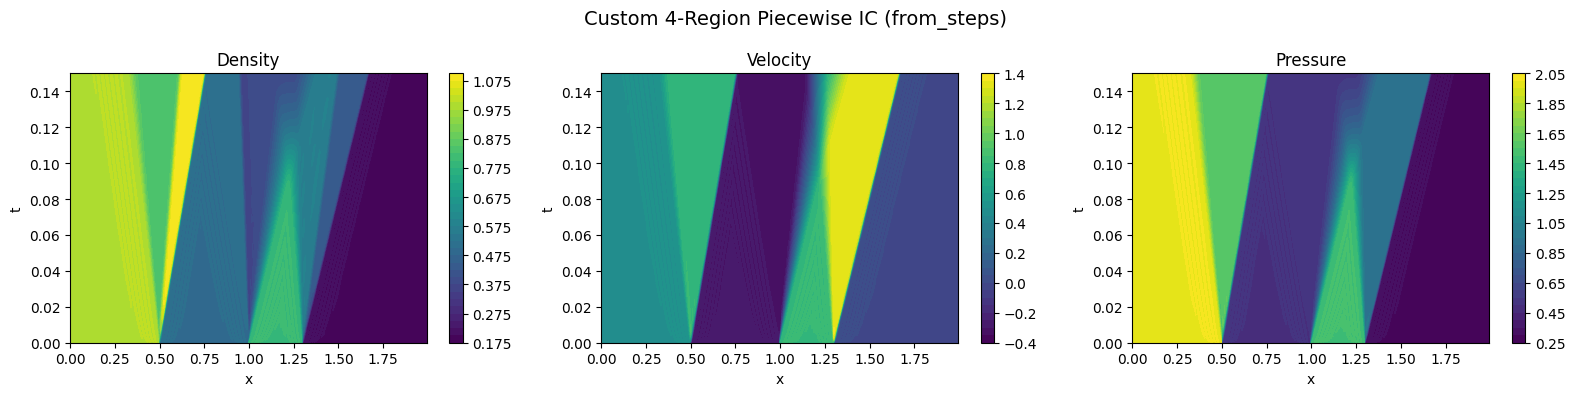

In [6]:
rho_steps = [(-0.5, 1.0), (0.0, 0.5), (0.3, 0.8), (1.0, 0.2)]
u_steps = [(-0.5, 0.5), (0.0, -0.3), (0.3, 0.8), (1.0, 0.0)]
p_steps = [(-0.5, 2.0), (0.0, 0.5), (0.3, 1.5), (1.0, 0.3)]

rho0, u0, p0 = from_steps(x, rho_steps=rho_steps, u_steps=u_steps, p_steps=p_steps)
sol = generate_one(rho0, u0, p0, dx=DX, dt=DT, nt=NT, gamma=GAMMA)
print(f"valid: {sol['valid']}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, key, title in zip(axes, ["rho", "u", "p"], ["Density", "Velocity", "Pressure"]):
    c = ax.contourf(sol["x"].numpy(), sol["t"].numpy(), sol[key].numpy(), levels=40, cmap="viridis")
    fig.colorbar(c, ax=ax)
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(title)
fig.suptitle("Custom 4-Region Piecewise IC (from_steps)", fontsize=14)
fig.tight_layout()
plt.show()

## 6. Batch Generation (`generate_n`)

Generate 6 random samples with k=3 pieces each (random rho, u, p per region).

Euler samples: 100%|██████████| 6/6 [00:02<00:00,  2.16it/s]


rho shape: torch.Size([6, 501, 400])
u   shape: torch.Size([6, 501, 400])
p   shape: torch.Size([6, 501, 400])
ic_xs shape: (6, 4)
ic_rho_ks: (6, 3)
ic_u_ks:   (6, 3)
ic_p_ks:   (6, 3)


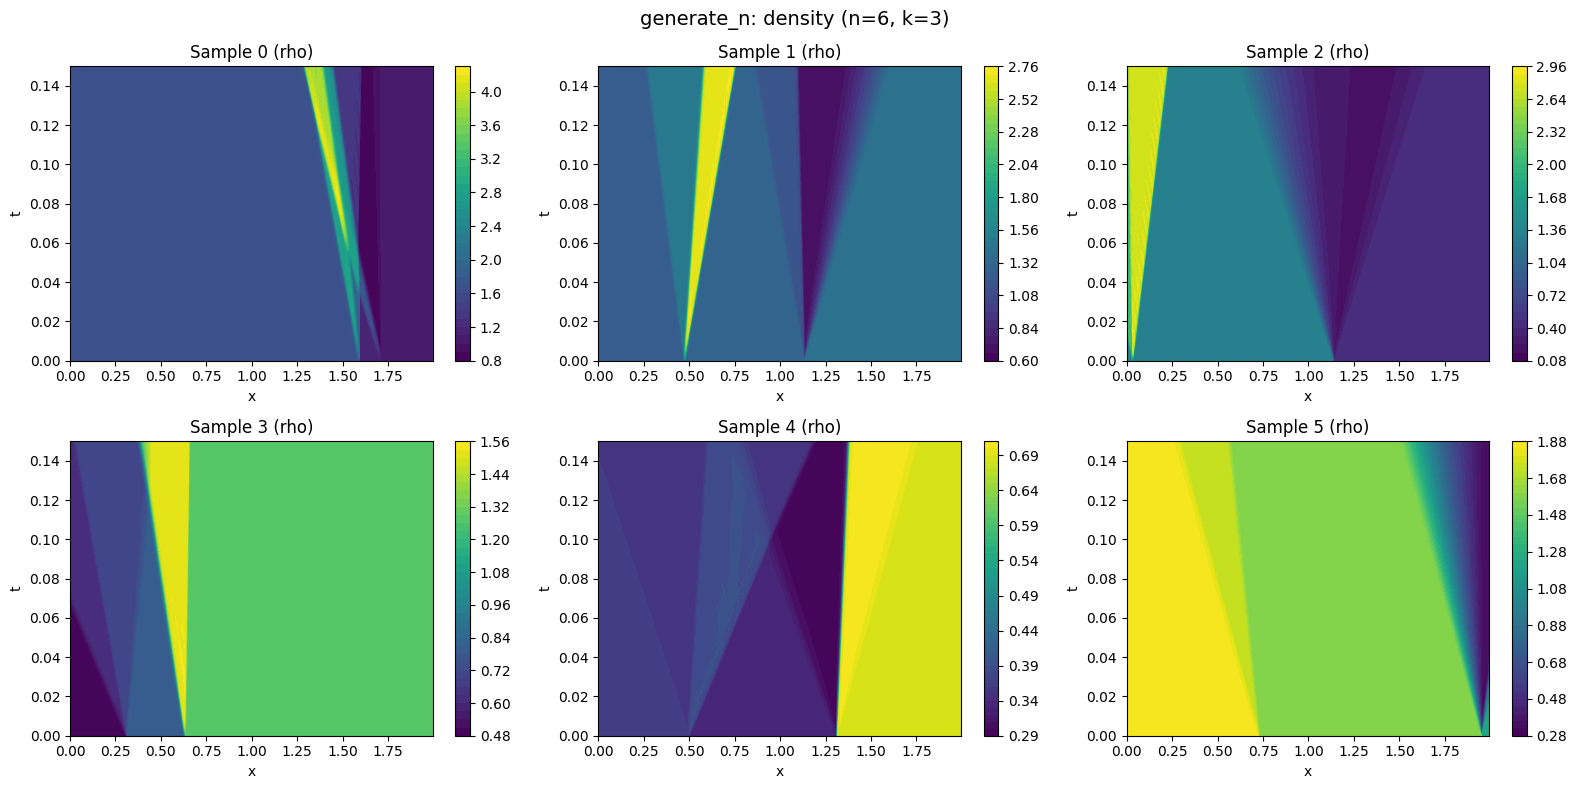

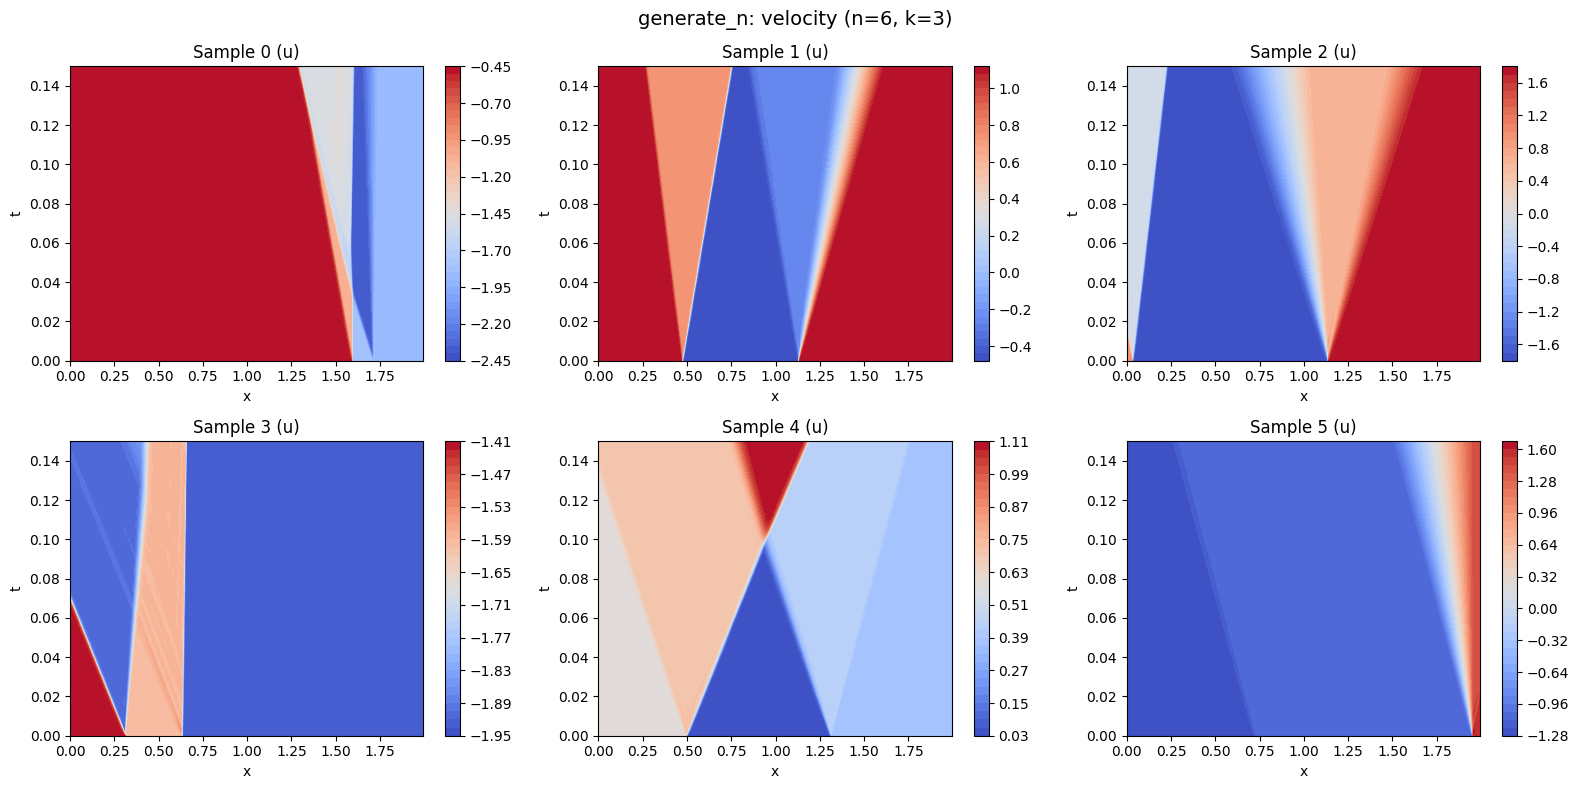

In [7]:
batch = generate_n(
    n=6, k=3, nx=NX, dx=DX, dt=DT, nt=NT, gamma=GAMMA, seed=42,
)

print(f"rho shape: {batch['rho'].shape}")
print(f"u   shape: {batch['u'].shape}")
print(f"p   shape: {batch['p'].shape}")
print(f"ic_xs shape: {batch['ic_xs'].shape}")
print(f"ic_rho_ks: {batch['ic_rho_ks'].shape}")
print(f"ic_u_ks:   {batch['ic_u_ks'].shape}")
print(f"ic_p_ks:   {batch['ic_p_ks'].shape}")

# Space-time density plots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    c = ax.contourf(batch["x"].numpy(), batch["t"].numpy(), batch["rho"][i].numpy(), levels=40, cmap="viridis")
    fig.colorbar(c, ax=ax)
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(f"Sample {i} (rho)")
fig.suptitle("generate_n: density (n=6, k=3)", fontsize=14)
fig.tight_layout()
plt.show()

# Space-time velocity plots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    c = ax.contourf(batch["x"].numpy(), batch["t"].numpy(), batch["u"][i].numpy(), levels=40, cmap="coolwarm")
    fig.colorbar(c, ax=ax)
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(f"Sample {i} (u)")
fig.suptitle("generate_n: velocity (n=6, k=3)", fontsize=14)
fig.tight_layout()
plt.show()

## 7. Physics Helpers

In [8]:
rho = torch.tensor([0.125, 0.5, 1.0, 2.0])
u = torch.tensor([0.0, 1.0, -0.5, 2.0])
p = torch.tensor([0.1, 0.5, 1.0, 5.0])
gamma = 1.4

# Primitive -> conservative -> primitive roundtrip
_, rho_u, E = primitive_to_conservative(rho, u, p, gamma)
rho2, u2, p2 = conservative_to_primitive(rho, rho_u, E, gamma)

print("=== Roundtrip test ===")
print(f"rho match: {torch.allclose(rho, rho2)}")
print(f"u   match: {torch.allclose(u, u2)}")
print(f"p   match: {torch.allclose(p, p2)}")

# Sound speed
c = sound_speed(rho, p, gamma)
c_expected = torch.sqrt(gamma * p / rho)
print(f"\nSound speed: {c.tolist()}")
print(f"Expected:    {c_expected.tolist()}")
print(f"Match: {torch.allclose(c, c_expected)}")

# Verify E = p/(gamma-1) + 0.5*rho*u^2
E_expected = p / (gamma - 1) + 0.5 * rho * u**2
print(f"\nE match: {torch.allclose(E, E_expected)}")

=== Roundtrip test ===
rho match: True
u   match: True
p   match: True

Sound speed: [1.058300495147705, 1.1832159757614136, 1.1832159757614136, 1.8708287477493286]
Expected:    [1.058300495147705, 1.1832159757614136, 1.1832159757614136, 1.8708287477493286]
Match: True

E match: True
